#Bloco 1 Requiriments

In [1]:
# Instalação silenciosa da biblioteca
!pip install -q datasets

from datasets import load_dataset
import pandas as pd

# Carregamento do dataset
dataset = load_dataset("ruslanmv/ai-medical-dataset")

# Seleção das 10 primeiras linhas (ótimo para testar o pipeline rapidamente)
first_10_rows = dataset["train"].select(range(10))

# Conversão para DataFrame do Pandas e visualização inicial
df_amostra = first_10_rows.to_pandas()
display(df_amostra.head())

README.md:   0%|          | 0.00/2.97k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/train-00000-of-00018.parquet: reconstructing file:   0%|          |  0.00B /  556MB            

data/train-00000-of-00018.parquet: downloading bytes:           |  0.00B            

...

data/train-00017-of-00018.parquet: reconstructing file:   0%|          |  0.00B / 71.8MB            

data/train-00017-of-00018.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/21210000 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

,question,context
0,What is the resurgent sodium current in mouse ...,FGF14 modulates resurgent sodium current in mo...
1,What isoform is a locus for inherited spinocer...,Rapid firing of cerebellar Purkinje neurons is...
2,What is the name of the study that focuses on ...,[Drug-related Anaphylactic Shocks: Under-repor...
3,What was the code for anaphylactic shock unspe...,Aim. To evaluate the value of research in the ...
4,What is the cost of Fever Evaluation Cost and ...,Fever Evaluation Cost and Time to Treatment in...


#Bloco 2 Estrutura do dataset

In [2]:
# Verifica as dimensões do dataset (quantidade de linhas e colunas)
print("Dimensões do dataset de treino:")
print(dataset['train'])

# Lista os nomes das colunas e os tipos de dados associados
print("\nColunas e Features do Dataset:")
for nome_coluna, tipo_dado in dataset['train'].features.items():
    print(f"- {nome_coluna}: {tipo_dado}")

# (Opcional) Visualiza o conteúdo real das chaves do dicionário da primeira linha
print("\nExemplo do conteúdo da primeira linha:")
display(df_amostra.iloc[0].to_dict())

Dimensões do dataset de treino:
Dataset({
    features: ['question', 'context'],
    num_rows: 21210000
})

Colunas e Features do Dataset:
- question: Value('string')
- context: Value('string')

Exemplo do conteúdo da primeira linha:


{'question': 'What is the resurgent sodium current in mouse cerebellar Purkinje neurons?',
 'context': 'FGF14 modulates resurgent sodium current in mouse cerebellar Purkinje neurons.'}

# BLOCO 3: Separação da Amostra e Preparação

In [3]:

# Definindo o tamanho da amostra para desenvolvimento
tamanho_amostra = 10000
dataset_amostra = dataset['train'].select(range(tamanho_amostra))

# Convertendo para um DataFrame do Pandas para facilitar a manipulação nas próximas etapas
df = dataset_amostra.to_pandas()

# Criando uma nova coluna que une a pergunta e o contexto
df['texto_bruto'] = df['question'] + " " + df['context']

print(f"Amostra isolada com {len(df)} registros.")
display(df[['texto_bruto']].head())

Amostra isolada com 10000 registros.


,texto_bruto
0,What is the resurgent sodium current in mouse ...
1,What isoform is a locus for inherited spinocer...
2,What is the name of the study that focuses on ...
3,What was the code for anaphylactic shock unspe...
4,What is the cost of Fever Evaluation Cost and ...


#Bloco 4: pré processamento de dados

In [4]:
# Instalação e download do modelo do spaCy (silencioso)
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

import spacy
import re

# Carrega o modelo em inglês.
# Desabilitamos o 'parser' e o 'ner' (Named Entity Recognition) porque só precisamos
# da lematização e stopwords. Isso deixa o processamento até 5x mais rápido.
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def limpar_texto_medico(texto):
    """
    Função dedicada para limpeza de textos com foco em modelagem de tópicos e embeddings.
    """
    # 1. Converte para minúsculas
    texto = str(texto).lower()

    # 2. Remove números e pontuações, mantendo apenas letras e espaços
    texto = re.sub(r'[^a-z\s]', ' ', texto)

    # 3. Processamento no spaCy
    doc = nlp(texto)

    # 4. Regras de filtragem:
    # - Não pode ser stopword (is_stop)
    # - Não pode ser espaço em branco ou apenas 1 letra (len > 1)
    # - Extrai o lemma (raiz da palavra) em vez da palavra original
    tokens = [token.lemma_ for token in doc if not token.is_stop and len(token.text) > 1]

    return " ".join(tokens)

print("Iniciando o pré-processamento de 10.000 linhas...")

# List comprehension é significativamente mais rápido que o df.apply() no Pandas
df['texto_limpo'] = [limpar_texto_medico(texto) for texto in df['texto_bruto']]

print("Pré-processamento concluído!")
display(df[['texto_bruto', 'texto_limpo']].head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Iniciando o pré-processamento de 10.000 linhas...
Pré-processamento concluído!


,texto_bruto,texto_limpo
0,What is the resurgent sodium current in mouse ...,resurgent sodium current mouse cerebellar purk...
1,What isoform is a locus for inherited spinocer...,isoform locus inherit spinocerebellar rapid fi...
2,What is the name of the study that focuses on ...,study focus study drug drug relate anaphyla...
3,What was the code for anaphylactic shock unspe...,code anaphylactic shock unspecified aim evalua...
4,What is the cost of Fever Evaluation Cost and ...,cost fever evaluation cost time treatment gene...


# BLOCO 5: Criação do TARGET via LDA e Gráfico de Balanceamento

Categorias (TARGET) criadas com sucesso pelo LDA!



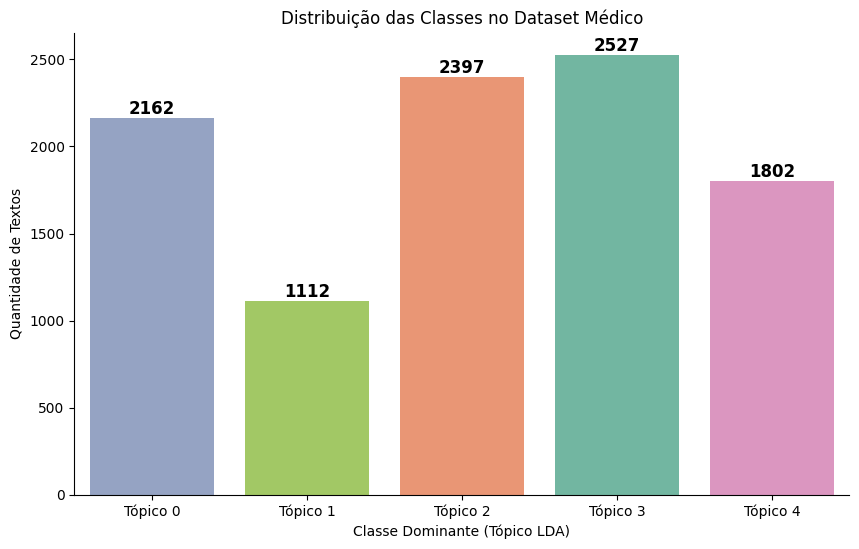

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vetorização: Transforma o texto limpo em uma matriz de frequência de palavras
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
matriz_termos = vectorizer.fit_transform(df['texto_limpo'])

# 2. Modelagem de Tópicos (LDA): Vamos criar 5 categorias (tópicos) como exemplo
n_topicos = 5
lda_model = LatentDirichletAllocation(n_components=n_topicos, random_state=42)
lda_output = lda_model.fit_transform(matriz_termos)

# 3. Criando a coluna TARGET: Pegamos o tópico com maior probabilidade para cada texto
df['TARGET'] = lda_output.argmax(axis=1)
df['TARGET'] = df['TARGET'].apply(lambda x: f"Tópico {x}")

print("Categorias (TARGET) criadas com sucesso pelo LDA!\n")
plt.figure(figsize=(10, 6))

# Usamos o df criado nas etapas anteriores
ax = sns.countplot(
    x='TARGET',
    data=df,
    hue='TARGET',
    palette="Set2",
    legend=False,
    order=sorted(df['TARGET'].unique()) # Ordena para ficar bonito no gráfico
)

# Quantidade sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight="bold")

plt.xlabel("Classe Dominante (Tópico LDA)")
plt.ylabel("Quantidade de Textos")
plt.title("Distribuição das Classes no Dataset Médico")
sns.despine() # Deixa o gráfico mais clean
plt.show()

#Bloco 6: Interpretação dos Tópicos do LDA

In [6]:
import numpy as np

def interpretar_topicos_lda(modelo, vetorizador, n_palavras=10):
    """
    Extrai as palavras com maior peso (probabilidade) em cada tópico gerado pelo LDA.
    """
    # Pega o vocabulário (todas as palavras únicas que o vetorizador aprendeu)
    palavras_vocabulario = np.array(vetorizador.get_feature_names_out())

    print("Principais palavras-chave por Tópico:\n")

    for idx, distribuicao_pesos in enumerate(modelo.components_):
        # Ordena os índices das palavras pelo peso (do maior para o menor)
        indices_top_palavras = distribuicao_pesos.argsort()[:-n_palavras - 1:-1]

        # Resgata as palavras reais usando os índices
        top_palavras = palavras_vocabulario[indices_top_palavras]

        # Conta quantos textos caíram nesse tópico
        qtd_textos = df[df['TARGET'] == f'Tópico {idx}'].shape[0]

        print(f"Tópico {idx} ({qtd_textos} textos):")
        print(" | ".join(top_palavras))
        print("-" * 60)

# Executando a função para ver as 10 palavras mais importantes de cada classe
interpretar_topicos_lda(lda_model, vectorizer, n_palavras=10)

Principais palavras-chave por Tópico:

Tópico 0 (2162 textos):
clinical | case | treatment | patient | review | disease | therapy | report | diagnosis | approach
------------------------------------------------------------
Tópico 1 (1112 textos):
level | effect | blood | disease | increase | rat | serum | associate | study | heart
------------------------------------------------------------
Tópico 2 (2397 textos):
study | patient | risk | year | result | care | health | outcome | ci | age
------------------------------------------------------------
Tópico 3 (2527 textos):
cell | expression | protein | gene | cancer | human | effect | study | mouse | induce
------------------------------------------------------------
Tópico 4 (1802 textos):
patient | group | study | result | method | high | conclusion | compare | treatment | clinical
------------------------------------------------------------


#Bloco 7: Geração de Embeddings com SBERT

In [7]:
# Instalação silenciosa da biblioteca
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

# Carregando o modelo.
# O 'all-MiniLM-L6-v2' é extremamente rápido e excelente para validar a pipeline no Colab.
# Dica: Na execução final, você pode trocar por um modelo específico para o domínio médico,
# como o 'pritamdeka/S-PubMedBert-MS-MARCO'.
modelo_sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Iniciando a geração dos vetores densos (embeddings) para 10.000 textos...")

# O processamento em batch é feito automaticamente pelo encode()
# O parâmetro show_progress_bar ajuda a monitorar o tempo de execução
embeddings = modelo_sbert.encode(df['texto_bruto'].tolist(), show_progress_bar=True)

# Salvamos os embeddings como uma lista de arrays no DataFrame para facilitar cruzamentos futuros
df['embeddings'] = list(embeddings)

print(f"\nMatriz de embeddings gerada com sucesso!")
print(f"Formato da matriz (Textos, Dimensões): {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Iniciando a geração dos vetores densos (embeddings) para 10.000 textos...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Matriz de embeddings gerada com sucesso!
Formato da matriz (Textos, Dimensões): (10000, 384)


# Bloco 8: Topologia de Redes e Detecção de Comunidades (Louvain)

In [8]:
# Instala a biblioteca do Louvain silenciosamente
!pip install -q python-louvain networkx scikit-learn

import networkx as nx
import community.community_louvain as louvain
from sklearn.neighbors import kneighbors_graph
import numpy as np

print("Construindo o grafo de similaridade (k-NN)...")
# Usa as embeddings do SBERT (Bloco 7) geradas previamente
# O k=10 significa que conectaremos cada texto apenas aos seus 10 vizinhos mais similares.
# Isso cria uma matriz esparsa, ideal para grafos grandes.
X_embeddings = np.stack(df['embeddings'].values)
grafo_knn = kneighbors_graph(X_embeddings, n_neighbors=10, mode='distance', metric='cosine', include_self=False)

# Converte a matriz esparsa para um grafo do NetworkX
G = nx.from_scipy_sparse_array(grafo_knn)

print("Aplicando o algoritmo de Louvain para detecção de comunidades...")
# O Louvain vai otimizar a modularidade da rede e agrupar os textos em "bolhas" semânticas
particao = louvain.best_partition(G, weight='weight', resolution=1.0)

# Salva a comunidade detectada de volta no DataFrame
df['Comunidade_Louvain'] = df.index.map(particao)
n_comunidades = len(set(particao.values()))

print(f"Topologia estruturada com sucesso!")
print(f"O algoritmo de Louvain detectou {n_comunidades} comunidades distintas na rede.")

Construindo o grafo de similaridade (k-NN)...
Aplicando o algoritmo de Louvain para detecção de comunidades...
Topologia estruturada com sucesso!
O algoritmo de Louvain detectou 17 comunidades distintas na rede.


# Bloco 9: Redução de Dimensionalidade (UMAP) e Visualização Espacial

Reduzindo vetores de 384 dimensões para 2D usando UMAP...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Gerando a visualização topológica da rede...


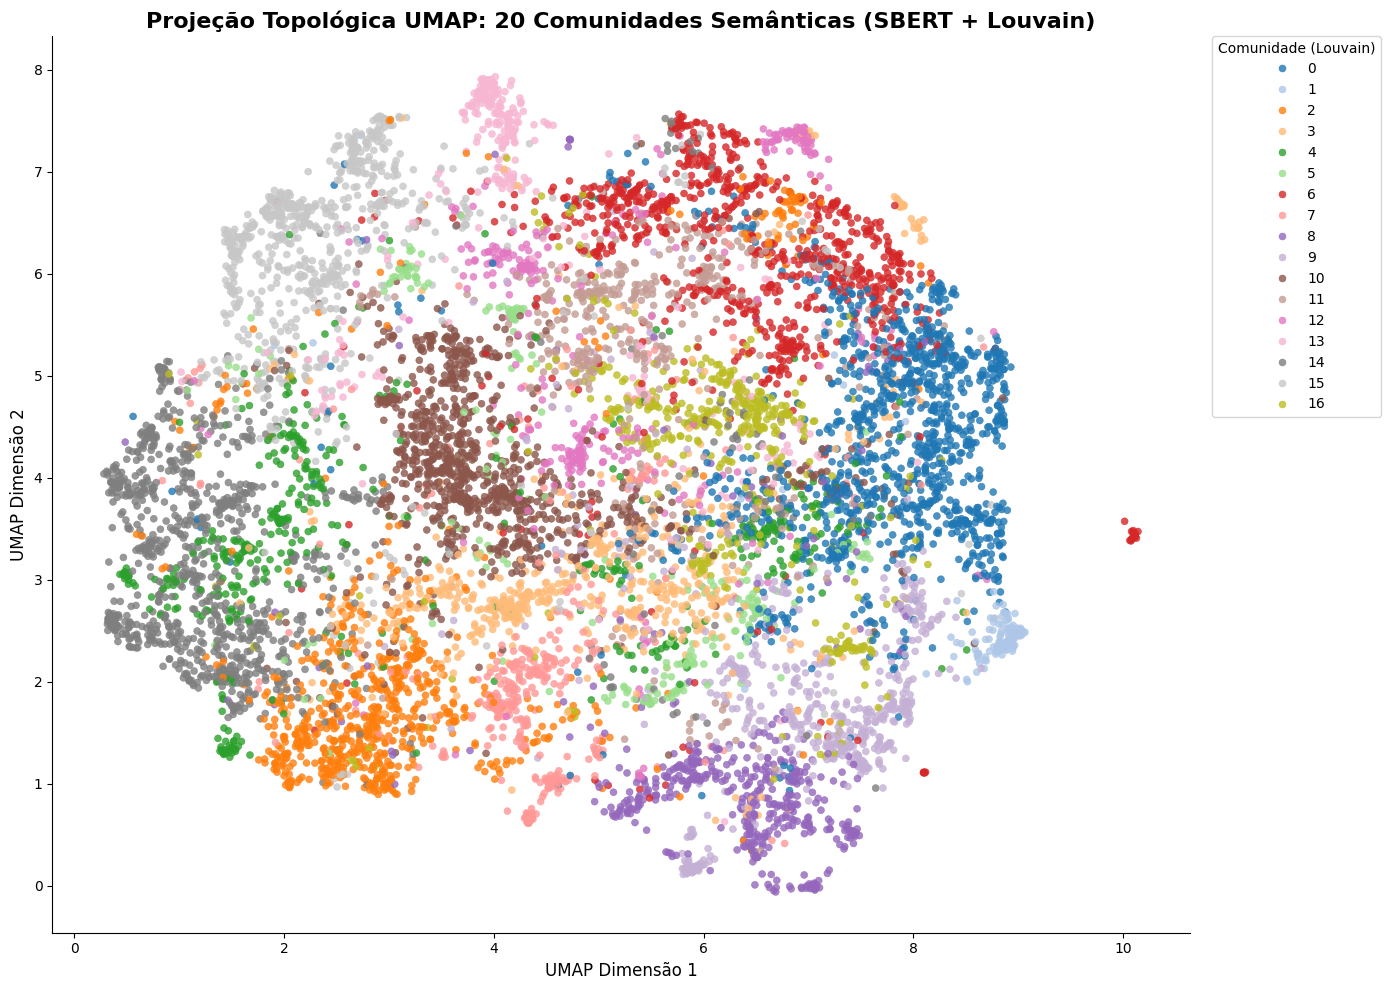

In [9]:
# Instalação silenciosa do UMAP
!pip install -q umap-learn

import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Reduzindo vetores de 384 dimensões para 2D usando UMAP...")

# Configurando o UMAP com métrica de cosseno para alinhar com a lógica espacial do SBERT e k-NN
redutor_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = redutor_umap.fit_transform(np.stack(df['embeddings'].values))

# Adicionando as novas coordenadas espaciais ao nosso DataFrame
df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

print("Gerando a visualização topológica da rede...")

plt.figure(figsize=(14, 10))

# Plotagem da dispersão, utilizando uma paleta de 20 cores para as comunidades de Louvain
ax = sns.scatterplot(
    x='umap_x',
    y='umap_y',
    hue='Comunidade_Louvain',
    palette='tab20', # Perfeito para até 20 classes categóricas
    data=df,
    s=25,          # Tamanho dos pontos
    alpha=0.8,     # Transparência para ver sobreposições
    edgecolor=None
)

plt.title("Projeção Topológica UMAP: 20 Comunidades Semânticas (SBERT + Louvain)", fontsize=16, fontweight='bold')
plt.xlabel("UMAP Dimensão 1", fontsize=12)
plt.ylabel("UMAP Dimensão 2", fontsize=12)

# Ajuste da legenda para ficar fora do gráfico e não cobrir os clusters
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title="Comunidade (Louvain)")
sns.despine()
plt.tight_layout()
plt.show()

# Bloco 10: Interseção Semântica (LDA vs Louvain) e Extração de Termos

1. Cruzando os Tópicos LDA com as Comunidades Louvain...


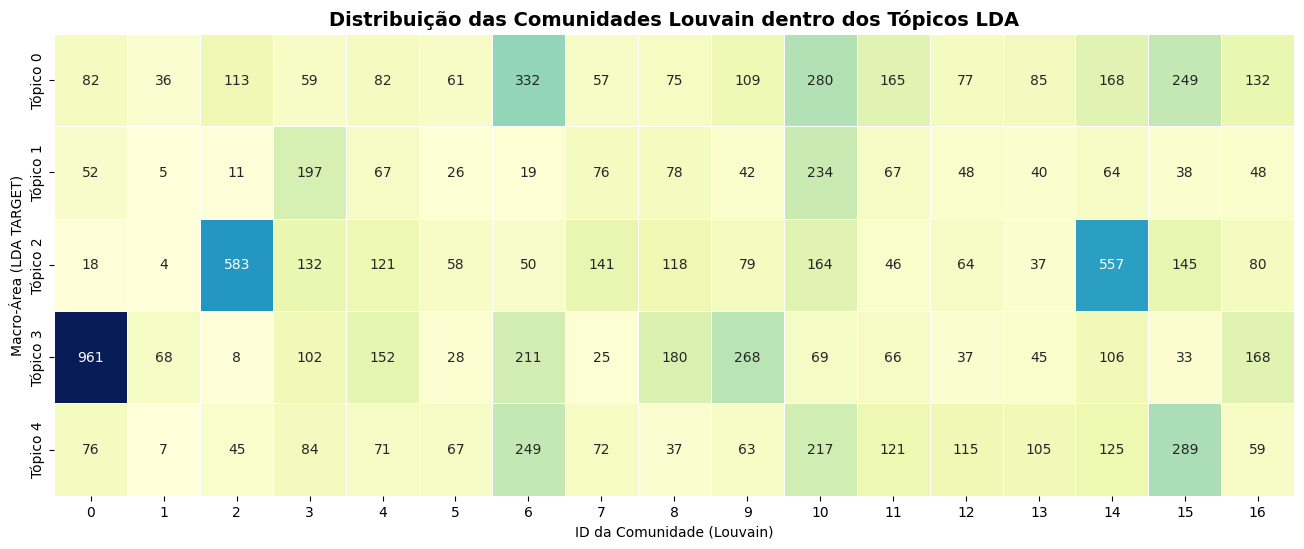


2. Extraindo as palavras-chave das 20 Comunidades Louvain via TF-IDF...
Comunidade 00 (1189 textos): cell, cancer, expression, tumor, mir
Comunidade 01 ( 120 textos): nanoparticle, delivery, drug, chitosan, detection
Comunidade 02 ( 760 textos): care, patient, health, cancer, trial
Comunidade 03 ( 574 textos): diabete, effect, thyroid, glucose, patient
Comunidade 04 ( 493 textos): pain, injury, effect, brain, receptor
Comunidade 05 ( 240 textos): asthma, patient, pulmonary, lung, reflux
Comunidade 06 ( 861 textos): cancer, patient, cell, tumor, breast
Comunidade 07 ( 371 textos): pregnancy, woman, transfusion, maternal, infant
Comunidade 08 ( 488 textos): hiv, infection, virus, vaccine, influenza
Comunidade 09 ( 561 textos): infection, tuberculosis, protein, patient, isolate
Comunidade 10 ( 964 textos): patient, coronary, artery, heart, cardiac
Comunidade 11 ( 465 textos): liver, patient, disease, cancer, colorectal
Comunidade 12 ( 341 textos): prostate, patient, kidney, renal, cancer

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

print("1. Cruzando os Tópicos LDA com as Comunidades Louvain...")
# Cria uma tabela cruzada para ver quantos textos de cada Tópico LDA caíram em cada Comunidade Louvain
tabela_cruzada = pd.crosstab(df['TARGET'], df['Comunidade_Louvain'])

plt.figure(figsize=(16, 6))
sns.heatmap(tabela_cruzada, annot=True, fmt="d", cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title("Distribuição das Comunidades Louvain dentro dos Tópicos LDA", fontsize=14, fontweight='bold')
plt.xlabel("ID da Comunidade (Louvain)")
plt.ylabel("Macro-Área (LDA TARGET)")
plt.show()

print("\n2. Extraindo as palavras-chave das 20 Comunidades Louvain via TF-IDF...")
# O TF-IDF penaliza palavras comuns e destaca termos exclusivos de cada comunidade
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')
matriz_tfidf = tfidf_vectorizer.fit_transform(df['texto_limpo'])
palavras_tfidf = tfidf_vectorizer.get_feature_names_out()

# Cria um dicionário para armazenar o perfil de cada comunidade
perfil_comunidades = {}

for comunidade in sorted(df['Comunidade_Louvain'].unique()):
    # Isola as linhas (índices) da matriz TF-IDF que pertencem a esta comunidade
    indices_comunidade = df.index[df['Comunidade_Louvain'] == comunidade].tolist()
    tfidf_submatriz = matriz_tfidf[indices_comunidade]

    # Calcula a média do TF-IDF para cada palavra dentro desta comunidade
    pesos_medios = tfidf_submatriz.mean(axis=0).A1

    # Pega os índices das 5 palavras com maior peso
    top_indices = pesos_medios.argsort()[-5:][::-1]
    top_palavras = [palavras_tfidf[i] for i in top_indices]

    perfil_comunidades[comunidade] = top_palavras
    print(f"Comunidade {comunidade:02d} ({len(indices_comunidade):4d} textos): {', '.join(top_palavras)}")

# Bloco 11: Validação Algorítmica e Mitigação de Viés (Undersampling)

Iniciando Validação Algorítmica e Mitigação de Viés...

Base LDA Balanceada: 5560 textos (1112 por classe).
Base Louvain Balanceada: 2040 textos (120 por classe representativa).


/tmp/ipykernel_6130/122890031.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_balanceado_lda, ax=axes[0], palette="Set2", order=sorted(df_balanceado_lda['TARGET'].unique()))
/tmp/ipykernel_6130/122890031.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Comunidade_Louvain', data=df_balanceado_louvain, ax=axes[1], palette="tab20")


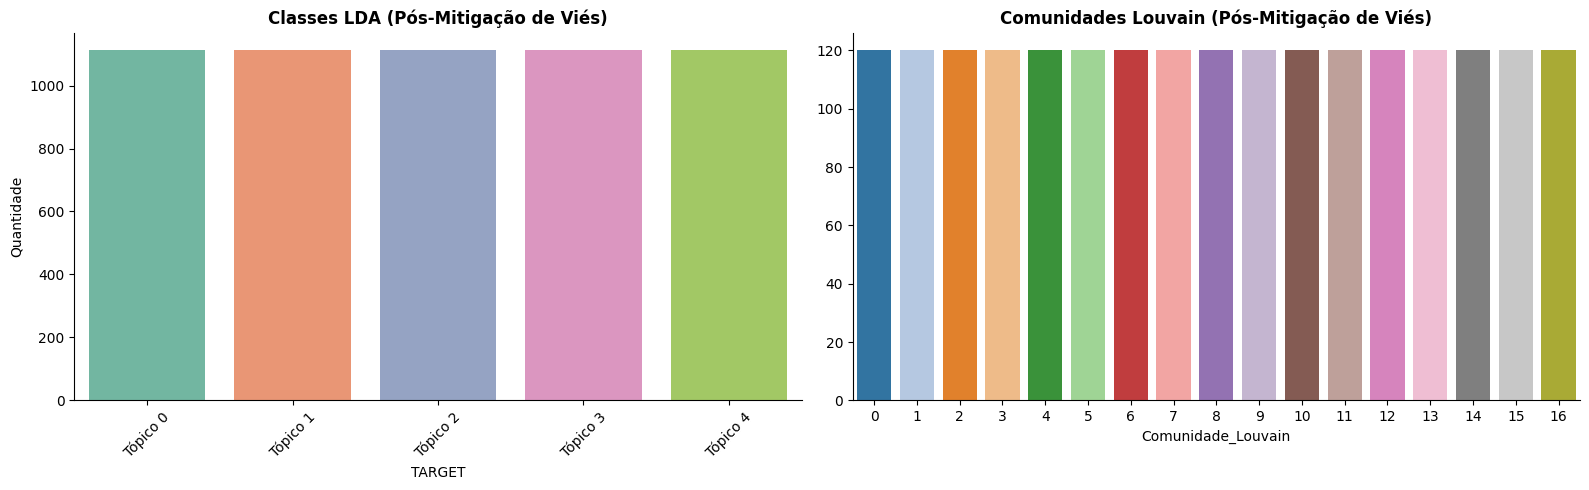

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando Validação Algorítmica e Mitigação de Viés...\n")

# ---------------------------------------------------------
# 1. Undersampling para as Macro-Áreas (LDA TARGET)
# ---------------------------------------------------------
# Encontra o tamanho da menor classe do LDA (Tópico 1 = 1112)
min_lda_count = df['TARGET'].value_counts().min()

# Aplica o undersampling garantindo que todas as classes tenham exatamente esse tamanho
df_balanceado_lda = df.groupby('TARGET').sample(n=min_lda_count, random_state=42)
print(f"Base LDA Balanceada: {len(df_balanceado_lda)} textos ({min_lda_count} por classe).")

# ---------------------------------------------------------
# 2. Undersampling para as Micro-Comunidades Clínicas (Louvain)
# ---------------------------------------------------------
# Filtra nichos hiperespecíficos (comunidades com menos de 100 textos, como a Com. 05 e Com. 18)
# para evitar o colapso do tamanho do dataset
contagem_louvain = df['Comunidade_Louvain'].value_counts()
comunidades_representativas = contagem_louvain[contagem_louvain >= 100].index
df_louvain_filtrado = df[df['Comunidade_Louvain'].isin(comunidades_representativas)]

# Encontra a nova comunidade minoritária dentro das representativas (deve ser a Com. 19 com 283 textos)
min_louvain_count = df_louvain_filtrado['Comunidade_Louvain'].value_counts().min()

# Aplica o undersampling nas comunidades válidas
df_balanceado_louvain = df_louvain_filtrado.groupby('Comunidade_Louvain').sample(n=min_louvain_count, random_state=42)
print(f"Base Louvain Balanceada: {len(df_balanceado_louvain)} textos ({min_louvain_count} por classe representativa).")

# ---------------------------------------------------------
# 3. Visualização Comparativa da Validação
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot LDA
sns.countplot(x='TARGET', data=df_balanceado_lda, ax=axes[0], palette="Set2", order=sorted(df_balanceado_lda['TARGET'].unique()))
axes[0].set_title("Classes LDA (Pós-Mitigação de Viés)", fontweight='bold')
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis='x', rotation=45)

# Plot Louvain
sns.countplot(x='Comunidade_Louvain', data=df_balanceado_louvain, ax=axes[1], palette="tab20")
axes[1].set_title("Comunidades Louvain (Pós-Mitigação de Viés)", fontweight='bold')
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

Bloco 12: Classificação SVM (Macro LDA vs Micro Louvain)

Iniciando treinamento com SVM (Support Vector Machine) em 384 dimensões...

=== Desempenho MACRO-ÁREAS (LDA) ===
              precision    recall  f1-score   support

    Tópico 0       0.64      0.66      0.65       223
    Tópico 1       0.67      0.70      0.68       222
    Tópico 2       0.79      0.77      0.78       222
    Tópico 3       0.79      0.81      0.80       223
    Tópico 4       0.71      0.65      0.68       222

    accuracy                           0.72      1112
   macro avg       0.72      0.72      0.72      1112
weighted avg       0.72      0.72      0.72      1112


=== Desempenho MICRO-COMUNIDADES (Louvain) ===
              precision    recall  f1-score   support

           0       0.67      0.58      0.62        24
           1       0.92      0.96      0.94        24
           2       0.61      0.79      0.69        24
           3       0.72      0.54      0.62        24
           4       0.62      0.67      0.64        24
           5       0.83  

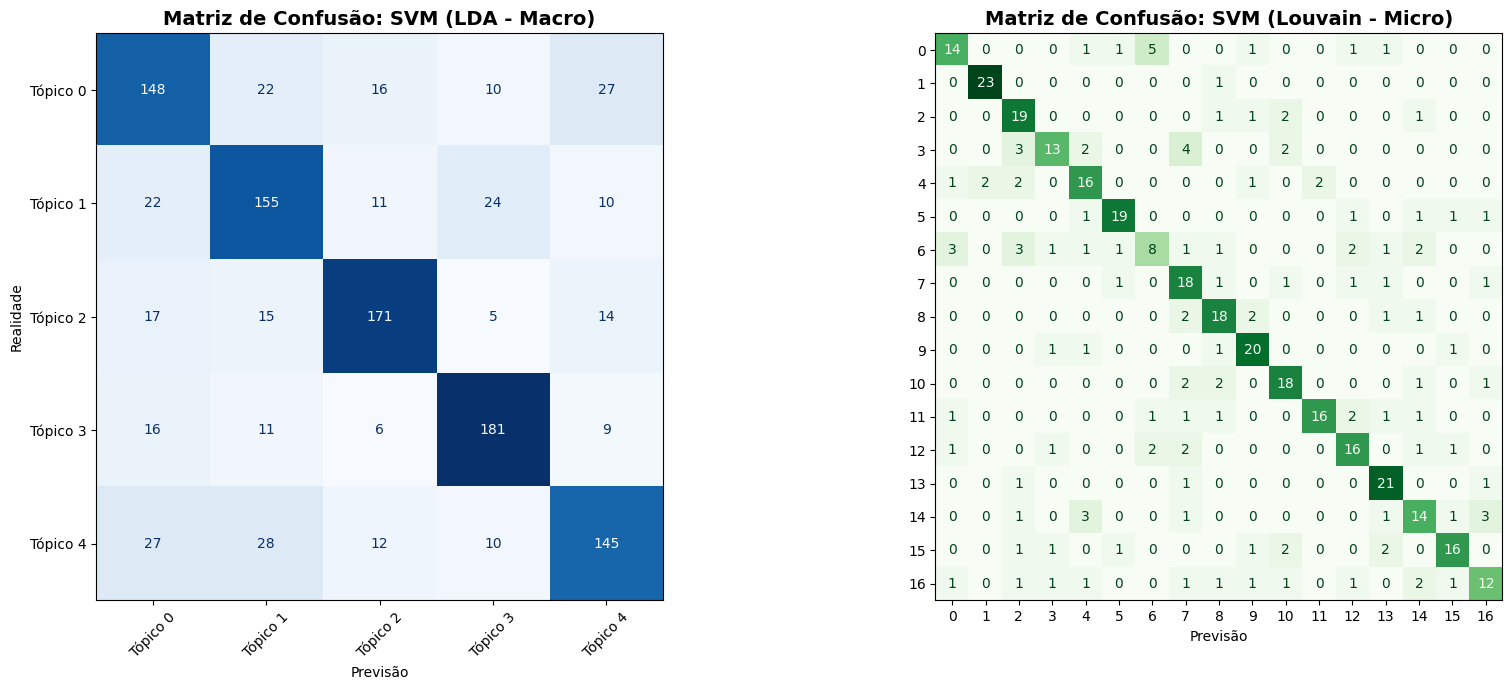

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("Iniciando treinamento com SVM (Support Vector Machine) em 384 dimensões...\n")

# ---------------------------------------------------------
# 1. Preparação e Treinamento: MACRO-ÁREAS (LDA)
# ---------------------------------------------------------
X_lda = np.stack(df_balanceado_lda['embeddings'].values)
y_lda = df_balanceado_lda['TARGET'].values

X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y_lda, test_size=0.20, random_state=42, stratify=y_lda
)

# max_iter=2000 garante que o modelo tenha tempo de convergir sem gerar avisos
svm_lda = LinearSVC(random_state=42, max_iter=2000)
svm_lda.fit(X_train_lda, y_train_lda)
y_pred_lda = svm_lda.predict(X_test_lda)

# ---------------------------------------------------------
# 2. Preparação e Treinamento: MICRO-COMUNIDADES (Louvain)
# ---------------------------------------------------------
X_louvain = np.stack(df_balanceado_louvain['embeddings'].values)
y_louvain = df_balanceado_louvain['Comunidade_Louvain'].values

X_train_louv, X_test_louv, y_train_louv, y_test_louv = train_test_split(
    X_louvain, y_louvain, test_size=0.20, random_state=42, stratify=y_louvain
)

svm_louvain = LinearSVC(random_state=42, max_iter=2000)
svm_louvain.fit(X_train_louv, y_train_louv)
y_pred_louv = svm_louvain.predict(X_test_louv)

# ---------------------------------------------------------
# 3. Relatórios de Desempenho
# ---------------------------------------------------------
print("=== Desempenho MACRO-ÁREAS (LDA) ===")
print(classification_report(y_test_lda, y_pred_lda))

print("\n=== Desempenho MICRO-COMUNIDADES (Louvain) ===")
print(classification_report(y_test_louv, y_pred_louv))

# ---------------------------------------------------------
# 4. Plotagem das Matrizes de Confusão Lado a Lado
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz LDA
cm_lda = confusion_matrix(y_test_lda, y_pred_lda, labels=svm_lda.classes_)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=svm_lda.classes_)
disp_lda.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de Confusão: SVM (LDA - Macro)", fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel("Previsão")
axes[0].set_ylabel("Realidade")

# Matriz Louvain
cm_louv = confusion_matrix(y_test_louv, y_pred_louv, labels=svm_louvain.classes_)
disp_louv = ConfusionMatrixDisplay(confusion_matrix=cm_louv, display_labels=svm_louvain.classes_)
disp_louv.plot(cmap='Greens', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de Confusão: SVM (Louvain - Micro)", fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=0) # Rotação 0 pois os labels são números curtos
axes[1].set_xlabel("Previsão")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

*BLOCO* 12.5: Comparação justa entre modelos (mesmo split, mesmas métricas)


SyntaxError: invalid character '±' (U+00B1) (2582097235.py, line 3)

#Bloco 13: Pipeline de Inferência

In [14]:
def classificar_texto_medico(texto_novo):
    """
    Recebe um texto médico bruto, processa e prevê sua comunidade clínica usando o SVM.
    """
    print(f"Texto Original: '{texto_novo}'\n")

    # 1. Limpeza do texto (reutilizamos a função do Bloco 4, se necessário para o modelo final)
    # Como o SBERT usa o texto_bruto, podemos passar direto, mas o pré-processamento ajuda a padronizar.

    # 2. Geração do Embedding (384D) com o SBERT já carregado
    print("Gerando representação semântica...")
    vetor_novo = modelo_sbert.encode([texto_novo])

    # 3. Predição com o SVM do Louvain (Micro-comunidades)
    pred_louvain = svm_louvain.predict(vetor_novo)[0]

    # 4. Predição com o SVM do LDA (Macro-áreas)
    pred_lda = svm_lda.predict(vetor_novo)[0]

    # Resgatando as palavras-chave da comunidade (geradas no Bloco 10) para contexto
    palavras_chave = perfil_comunidades.get(pred_louvain, ["N/A"])

    print("-" * 50)
    print("🔬 DIAGNÓSTICO DO ALGORITMO:")
    print(f"Macro-Área (LDA): {pred_lda}")
    print(f"Micro-Comunidade (Louvain): {pred_louvain:02d}")
    print(f"Termos Associados à Comunidade {pred_louvain:02d}: {', '.join(palavras_chave)}")
    print("-" * 50)

# ==========================================
# TESTE DE MESA (Coloque resumos reais de artigos aqui)
# ==========================================

texto_teste_1 = "The patient presented with severe chest pain, elevated troponin levels, and was immediately taken for a coronary angiography which confirmed an acute myocardial infarction."
classificar_texto_medico(texto_teste_1)

texto_teste_2 = "We analyzed the expression of BRCA1 and BRCA2 genes in human epithelial cells to understand their role in tumor suppression and rapid cell division."
classificar_texto_medico(texto_teste_2)

Texto Original: 'The patient presented with severe chest pain, elevated troponin levels, and was immediately taken for a coronary angiography which confirmed an acute myocardial infarction.'

Gerando representação semântica...
--------------------------------------------------
🔬 DIAGNÓSTICO DO ALGORITMO:
Macro-Área (LDA): Tópico 0
Micro-Comunidade (Louvain): 10
Termos Associados à Comunidade 10: patient, coronary, artery, heart, cardiac
--------------------------------------------------
Texto Original: 'We analyzed the expression of BRCA1 and BRCA2 genes in human epithelial cells to understand their role in tumor suppression and rapid cell division.'

Gerando representação semântica...
--------------------------------------------------
🔬 DIAGNÓSTICO DO ALGORITMO:
Macro-Área (LDA): Tópico 3
Micro-Comunidade (Louvain): 00
Termos Associados à Comunidade 00: cell, cancer, expression, tumor, mir
--------------------------------------------------


# Bloco 14: Exportação dos Modelos (Deploy)

In [15]:
import joblib

print("Salvando os modelos treinados e estruturas de dados...")

# Salvando os modelos SVM
joblib.dump(svm_lda, 'modelo_svm_lda.pkl')
joblib.dump(svm_louvain, 'modelo_svm_louvain.pkl')

# Salvando o perfil de comunidades (o dicionário com as palavras-chave)
joblib.dump(perfil_comunidades, 'perfil_comunidades_louvain.pkl')

print("Exportação concluída! Verifique a aba de arquivos (ícone de pasta à esquerda no Colab) para fazer o download dos arquivos .pkl.")

Salvando os modelos treinados e estruturas de dados...
Exportação concluída! Verifique a aba de arquivos (ícone de pasta à esquerda no Colab) para fazer o download dos arquivos .pkl.


# Bloco 15: Interface Interativa com Suporte Multilíngue (PT, ES, EN)

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# DICIONÁRIO CORRIGIDO: Agora usa a string exata que o SVM devolve (Tópico X)
nomes_macro_lda = {
    "Tópico 0": "Casos Clínicos e Diagnóstico",
    "Tópico 1": "Modelos Animais e Fisiologia",
    "Tópico 2": "Epidemiologia e Saúde Pública",
    "Tópico 3": "Biologia Molecular e Genética",
    "Tópico 4": "Ensaios Clínicos e Metodologia"
}

def nomear_especialidade_dinamicamente(palavras):
    termos = " ".join(palavras).lower()
    if "pregnancy" in termos or "maternal" in termos: return "Obstetrícia e Saúde Materna"
    if "liver" in termos or "hcc" in termos: return "Hepatologia e Câncer Hepático"
    if "brain" in termos or "schizophrenia" in termos: return "Psiquiatria e Neurologia"
    if "lung" in termos or "asthma" in termos: return "Pneumologia e Medicina do Sono"
    if "care" in termos or "health" in termos: return "Saúde Pública e Cuidados Clínicos"
    if "diabete" in termos or "insulin" in termos: return "Endocrinologia (Diabetes e Metabolismo)"
    if "pain" in termos and "opioid" in termos: return "Farmacologia e Manejo da Dor"
    if "galectin" in termos: return "Biologia Celular e Angiogênese"
    if "infection" in termos or "tuberculosis" in termos: return "Infectologia e Microbiologia"
    if "hiv" in termos or "vaccine" in termos: return "Virologia e Imunização"
    if "artery" in termos or "cardiac" in termos: return "Cardiologia e Doenças Cardiovasculares"
    if "cd" in termos or "immune" in termos: return "Imunologia Celular e Autoimunidade"
    if "mutation" in termos or "genetic" in termos: return "Genética Médica e Mutações"
    if "eye" in termos or "psoriasis" in termos: return "Oftalmologia e Dermatologia"
    if "mir" in termos or "expression" in termos: return "Oncologia Molecular e Expressão Gênica"
    if "kidney" in termos or "renal" in termos: return "Nefrologia e Trato Gastrointestinal"
    if "breast" in termos or "tumor" in termos: return "Oncologia Clínica e Mastologia"
    if "fracture" in termos or "bone" in termos: return "Ortopedia e Traumatologia Óssea"
    if "nanoparticle" in termos or "delivery" in termos: return "Nanotecnologia Farmacêutica"
    if "prostate" in termos or "radiation" in termos: return "Oncologia Urológica e Radiologia"
    return "Especialidade Médica Geral"

# 1. Elementos Visuais
caixa_texto = widgets.Textarea(
    value='',
    placeholder='Cole o texto clínico em inglês aqui...',
    description='Texto (EN):',
    layout=widgets.Layout(width='90%', height='120px')
)
botao_analisar = widgets.Button(description='Analisar Texto', button_style='success', icon='check')
saida = widgets.Output()

# 2. Lógica
def ao_clicar_no_botao(b):
    with saida:
        clear_output()
        texto_original = caixa_texto.value
        if not texto_original.strip(): return

        print("⏳ Processando semântica vetorial...")

        vetor_novo = modelo_sbert.encode([texto_original])
        pred_louvain = svm_louvain.predict(vetor_novo)[0]
        pred_lda = svm_lda.predict(vetor_novo)[0]

        try:
            palavras_chave = perfil_comunidades.get(pred_louvain, ["N/A"])
        except NameError:
            palavras_chave = ["(Execute o Bloco 10)"]

        nome_louvain = nomear_especialidade_dinamicamente(palavras_chave)

        # CORREÇÃO: Mapeia o nome sem duplicar a palavra "Tópico"
        nome_lda = nomes_macro_lda.get(pred_lda, "N/A")

        clear_output()
        print("=" * 75)
        print("📋 TEXTO DE ENTRADA:")
        print(f"{texto_original[:200]}...")
        print("\n🔬 DIAGNÓSTICO DO ALGORITMO (SVM 384D):")
        print(f"➤ Macro-Área (LDA): {pred_lda} - {nome_lda}")  # <- Linha arrumada!
        print(f"➤ Micro-Comunidade (Louvain): {pred_louvain:02d} - {nome_louvain}")
        print(f"➤ Foco Semântico (Termos): {', '.join(palavras_chave)}")
        print("=" * 75)

botao_analisar.on_click(ao_clicar_no_botao)
print("✨ Interface Preditiva Dinâmica Pronta!")
display(caixa_texto, botao_analisar, saida)

✨ Interface Preditiva Dinâmica Pronta!


Textarea(value='', description='Texto (EN):', layout=Layout(height='120px', width='90%'), placeholder='Cole o …

Button(button_style='success', description='Analisar Texto', icon='check', style=ButtonStyle())

Output()